## Testing Gaussian Pyramid Matched Filter
This notebook demonstrates the effectiveness of combining Gaussian pyramids with a matched filter implementation on an image of a microcrack.

### About Matched Filter
Similar to [the notebook on testing matched filters](mf_ccd.ipynb), this notebook uses [technique developed to detect cracks on concrete bridges](https://rdcu.be/fhYiN).

See more on the pure matched filter implementation using the link above.

### About Gaussian Pyramids
Normally, images are represented using a two-dimensional matrix of pixels (color or gray-value intensity). With Gaussian pyramids, we construct multiple representations of the same image but downsampled the higher the level we go.

In the case of template matching, this allows us to find cracks of different sizes at each level. Ideally, this pyramid approach will match cracks of variable size.

See more about pyramids [here](https://en.wikipedia.org/wiki/Pyramid_%28image_processing%29).


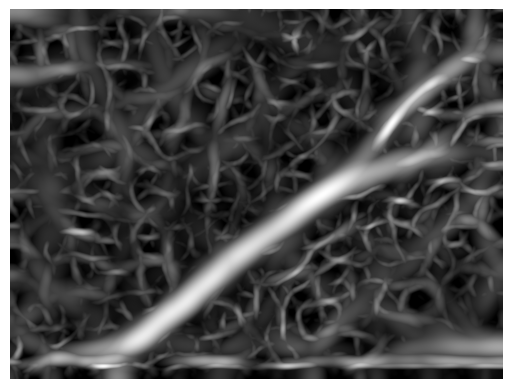

In [272]:
import matched_filter as mf
import matplotlib.pyplot as plt

templates = mf.generate_kernels(sigma=8.0, L=48, angle_step=15)
mask, response = mf.apply_pyramid_matched_filter_from_path(
    "../images/0098.tif", templates, levels=3
)
plt.imshow(response, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
from scripts import score
import cv2

img = cv2.imread('../images/annotated/0098.png', cv2.IMREAD_GRAYSCALE)
assert img is not None
ground_truth : cv2.typing.MatLike = img

print(f"ROC:\t{score.roc_auc(response, ground_truth):.2%}")
print(f"PR:\t{score.pr_auc(response, ground_truth):.2%}")

ROC:	95.84%
PR:	76.72%


Notice that the pyramid variation of the matched filter approach produces what appears to be brush strokes.

> My conjecture is that these brush strokes correspond to potential areas where multiple levels happened to respond decently to pixels in the same neighborhood. The darkest regions represent areas where no level seemed to respond at all.

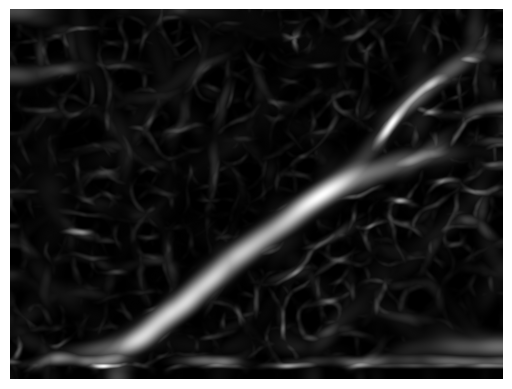

In [ ]:
from scripts import correction

gamma_corrected = correction.apply_gamma_correction(response)
cv2.normalize(gamma_corrected, gamma_corrected, 0.0, 1.0, cv2.NORM_MINMAX)
plt.imshow(gamma_corrected, cmap="gray")
plt.axis("off")
plt.show()

In [275]:
print(f"ROC:\t{score.roc_auc(gamma_corrected, ground_truth):.2%}")
print(f"PR:\t{score.pr_auc(gamma_corrected, ground_truth):.2%}")

ROC:	95.84%
PR:	76.72%


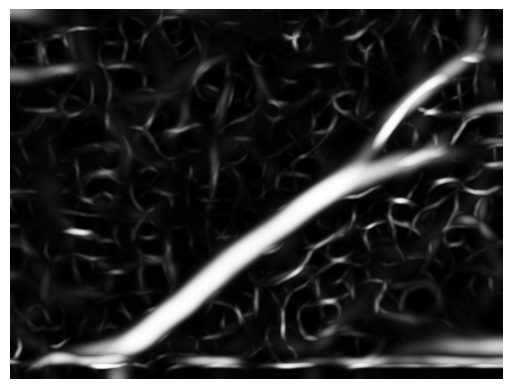

In [276]:
sigmoid_corrected = correction.apply_sigmoid_stretch(response, midpoint=0.5)
cv2.normalize(sigmoid_corrected, sigmoid_corrected, 0.0, 1.0, cv2.NORM_MINMAX)
plt.imshow(sigmoid_corrected, cmap='gray')
plt.axis('off')
plt.show()

In [277]:
print(f"ROC:\t{score.roc_auc(sigmoid_corrected, ground_truth):.2%}")
print(f"PR:\t{score.pr_auc(sigmoid_corrected, ground_truth):.2%}")

ROC:	95.84%
PR:	76.72%


Both gamma correction and sigmoid stretching exentuate responses within the expected crack region. As we do below, thresholding and cleaning with connected component denoising is required to convert these to masks.

> Unlike the single-size matched filter approach, it seems that CCD is required even for hysteresis thresholding.

## Binary Thresholding with CCD

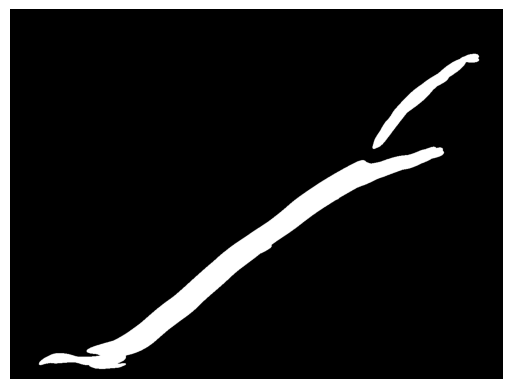

In [278]:
cleaned = mf.ccd(mask, int(mask.size / 200))
plt.imshow(cleaned, cmap='gray')
plt.axis('off')
plt.show()

In [279]:
print(f"IoU:\t{score.iou(cleaned, ground_truth):.2%}")
print(f"Dice:\t{score.dice(cleaned, ground_truth):.2%}")
print(f"Error:\t{score.percent_err(cleaned, ground_truth):.2%}")

IoU:	63.34%
Dice:	77.56%
Error:	2.80%


## Hysteresis Thresholding with CCD

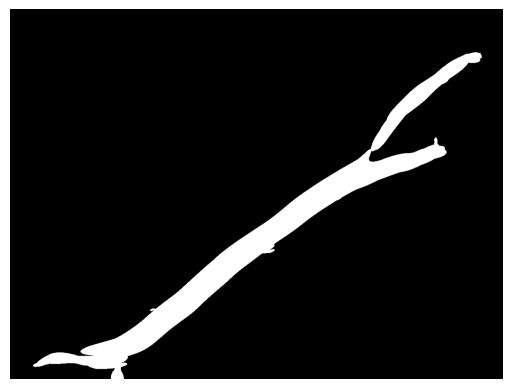

In [280]:
import numpy as np
from skimage.filters import apply_hysteresis_threshold

hysteresis_binary = apply_hysteresis_threshold(response, low=0.45, high=0.7)
hysteresis_mask = (hysteresis_binary * 255).astype(np.uint8)
cleaned_hysteresis = mf.ccd(hysteresis_mask, int(hysteresis_mask.size / 100))
plt.imshow(cleaned_hysteresis, cmap='gray')
plt.axis('off')
plt.show()

In [281]:
print(f"IoU:\t{score.iou(cleaned_hysteresis, ground_truth):.2%}")
print(f"Dice:\t{score.dice(cleaned_hysteresis, ground_truth):.2%}")
print(f"Error:\t{score.percent_err(cleaned_hysteresis, ground_truth):.2%}")

IoU:	65.12%
Dice:	78.88%
Error:	2.82%


## Gamma Correction Thresholding with CCD

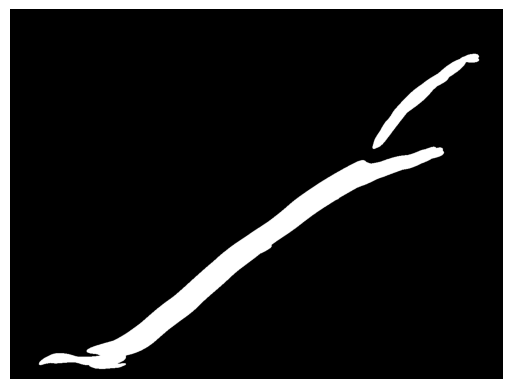

In [282]:
_, gamma_binary = cv2.threshold(gamma_corrected, 0.25, 1.0, cv2.THRESH_BINARY)
gamma_mask = (gamma_binary * 255).astype(np.uint8)
cleaned_gamma = mf.ccd(gamma_mask, int(gamma_mask.size / 200))
plt.imshow(cleaned_gamma, cmap="gray")
plt.axis("off")
plt.show()

In [283]:
print(f"IoU:\t{score.iou(cleaned_gamma, ground_truth):.2%}")
print(f"Dice:\t{score.dice(cleaned_gamma, ground_truth):.2%}")
print(f"Error:\t{score.percent_err(cleaned_gamma, ground_truth):.2%}")

IoU:	63.34%
Dice:	77.56%
Error:	2.80%


## Sigmoid Stretching Thresholding with CCD

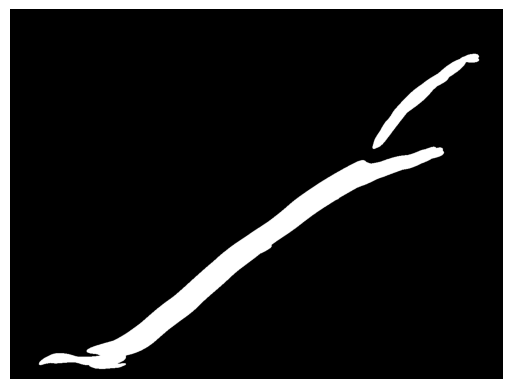

In [284]:
_, sigmoid_binary = cv2.threshold(sigmoid_corrected, 0.5, 1.0, cv2.THRESH_BINARY)
sigmoid_mask = (sigmoid_binary * 255).astype(np.uint8)
cleaned_sigmoid = mf.ccd(sigmoid_mask, int(sigmoid_mask.size / 200))
plt.imshow(cleaned_sigmoid, cmap='gray')
plt.axis('off')
plt.show()

In [285]:
print(f"IoU:\t{score.iou(cleaned_sigmoid, ground_truth):.2%}")
print(f"Dice:\t{score.dice(cleaned_sigmoid, ground_truth):.2%}")
print(f"Error:\t{score.percent_err(cleaned_sigmoid, ground_truth):.2%}")

IoU:	63.34%
Dice:	77.56%
Error:	2.80%
